In [1]:
!pip install tf-levenberg-marquardt 

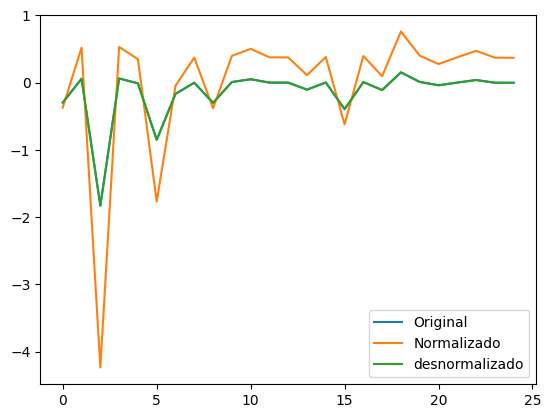

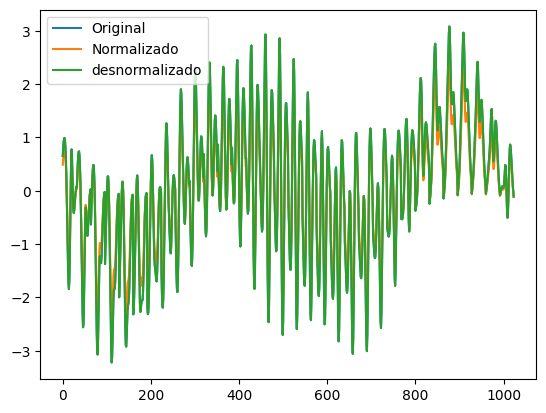

In [2]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

scaler = StandardScaler()
out_scaler = StandardScaler()

def peaks(grid):
    x = np.linspace(-2, 2, grid)
    y = np.linspace(-2, 2, grid)
    x, y = np.meshgrid(x, y)
    z = 3*(1-x)**2 * np.exp(-(x**2) - (y+1)**2) - 10*(x/5 - x**3 - y**5) * np.exp(-x**2 - y**2) - 1/3 * np.exp(-(x+1)**2 - y**2)
    return x, y, z

def create_dataframe_(filepath, grid):
    x = np.linspace(-2, 2, grid)
    y = np.linspace(-2, 2, grid)
    x, y = np.meshgrid(x, y)
    z = 3*(1-x)**2 * np.exp(-(x**2) - (y+1)**2) - 10*(x/5 - x**3 - y**5) * np.exp(-x**2 - y**2) - 1/3 * np.exp(-(x+1)**2 - y**2)
    df = pd.read_excel(filepath)
    z_pred_25 = df['Z_pred'].values.reshape(-1, 1)
    z_25= z.flatten().reshape(-1, 1) - z_pred_25
    data = {'X': x.flatten(), 'Y': y.flatten(), 'Z': z_25.flatten()}
    df = pd.DataFrame(data)
    return df

def create_dataframe(grid):
   x, y, z = peaks(grid)
   data = {'X': x.flatten(), 'Y': y.flatten(), 'Z': z.flatten()}
   df = pd.DataFrame(data)
   return df

def show_norm(df, label="Peaks", plot=False):
    df_norm = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)
    df_denorm = pd.DataFrame(scaler.inverse_transform(df_norm), columns=df_norm.columns)

    if (plot):
        df.plot(title=f"{label}: Original data")
        df_norm.plot(title=f"{label}: Normalized data")
        df_denorm.plot(title=f"{label}: Denormalized data")
    return (df_norm)


def test_out_scaler(df):
    out = df["Z"].values.reshape(-1, 1)  
    plt.plot(out, label='Original')
    out_scaler.fit(out)
    norm = out_scaler.transform(out)
    plt.plot(norm, label='Normalizado')
    plt.plot(out_scaler.inverse_transform(norm), label='desnormalizado')
    plt.legend()
    plt.show()


df_25 = create_dataframe_(f"25_model_12_6_0.xlsx", grid=5)
df_25_norm = show_norm(df_25)
test_out_scaler(df_25)

df_1000 = create_dataframe_(f"1000_model_12_6_0.xlsx",grid=32)
df_1000_norm = show_norm(df_1000)
test_out_scaler(df_1000)



In [3]:
def split_df(df):
    _input = np.vstack([df['X'], df['Y']]).T
    _output = np.array(df['Z'])
    return (_input, _output)

In [4]:
import tensorflow as tf
import numpy as np
from keras import regularizers
from keras import initializers
import tf_levenberg_marquardt as lm

# layers, neurons
class ShuffleArchitecture:
    def __init__(self, input_size, hidden_sizes, output_size, act_h, act_o, param_reg):
        self.input_size = input_size
        self.hidden_sizes = hidden_sizes
        self.output_size = output_size
        self.act_h = act_h
        self.act_o = act_o
        self.regularizer = regularizers.L2(param_reg)
        self.initializer = initializers.RandomUniform(minval=-0.5, maxval=0.5, seed=np.random.randint(1, 10000))

    def compute_k(self):
        total_parameters = 0
        for layer in self.model.layers:
            weights = layer.get_weights()
            if len(weights) > 0:  
                for w in weights:
                    total_parameters += np.prod(w.shape)
        return total_parameters
        
    def set_architecture(self):
        self.model = tf.keras.Sequential()
        self.model.add(tf.keras.layers.Dense(self.hidden_sizes[0],
                        input_shape=(self.input_size,),
                        activation=self.act_h,
                        kernel_regularizer=self.regularizer,
                        kernel_initializer=self.initializer,                        
                        ))  # input layer

        for size in self.hidden_sizes[1:]:  # hidden layers
            self.model.add(tf.keras.layers.Dense(size,
                            activation=self.act_h,
                            kernel_regularizer=self.regularizer,
                            kernel_initializer=self.initializer,  
                        ))

        self.model.add(tf.keras.layers.Dense(self.output_size,
                        activation=self.act_o,
                        kernel_regularizer=self.regularizer,
                        kernel_initializer=self.initializer,  
                        ))  # output layer

    def create_model(self, _learning_rate):
        mse_loss = lm.loss.MeanSquaredError()

        self.model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=_learning_rate),
            loss=tf.keras.losses.MeanSquaredError(),
        )
        self.lm_model = lm.model.ModelWrapper(
            tf.keras.models.clone_model(self.model)
        )
        self.lm_model.compile(
            optimizer=tf.keras.optimizers.SGD(learning_rate=_learning_rate),
             loss=lm.loss.MeanSquaredError()
        )
        return self.lm_model


2025-10-04 17:02:29.365554: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-10-04 17:02:36.858899: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-10-04 17:02:36.859020: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-10-04 17:02:38.132800: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-10-04 17:02:40.339514: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-10-04 17:02:40.340146: I tensorflow/core/platform/cpu_feature_guard.cc:1

In [5]:
from sklearn.model_selection import train_test_split
from keras.callbacks import EarlyStopping
from sklearn.metrics import r2_score, mean_squared_error, root_mean_squared_error, mean_absolute_percentage_error 

class TrainWithSmallDataset:
    def __init__(self, batch_size=1000):
        self.batch_size = batch_size
        self.betters = []
        self.k = 0

    def create_dataset(self, input, output):
      input = tf.expand_dims(tf.cast(input, tf.float32), axis=-1)
      output = tf.expand_dims(tf.cast(output, tf.float32), axis=-1)
      dataset = tf.data.Dataset.from_tensor_slices((input, output))
      dataset = dataset.shuffle(len(input))
      dataset = dataset.batch(self.batch_size).cache()
      dataset = dataset.prefetch(tf.data.experimental.AUTOTUNE)
      return (dataset, input, output)

    def split_dataset(self, input, output, sup_input, sup_output):
      input_train, input_vt, output_train, output_vt = train_test_split(input, output, test_size=0.3, shuffle = True)
      input_val, input_test, output_val, output_test = train_test_split(input_vt, output_vt, test_size=0.5, shuffle = True)

      self.train_dataset, self.train_input, self.train_output = self.create_dataset(input_train, output_train)
      self.val_dataset, self.val_input, self.val_output = self.create_dataset(input_val, output_val)
      self.test_dataset, self.test_input, self.test_output = self.create_dataset(input_test, output_test)
      self.vt_dataset, self.vt_input, self.vt_output = self.create_dataset(input_vt, output_vt)
      self.sup_dataset, self.sup_input, self.sup_output = self.create_dataset(sup_input, sup_output)
      self.dataset, self.input, self.output = self.create_dataset(input, output)

      self._data = (input, output)
      self._train = (input_train, output_train)
      self._vt = (input_vt, output_vt)
      self._val = (input_val, output_val)
      self._test = (input_test, output_test)
      self._sup = (sup_input, sup_output)

    def train_using_lm(self, train_dataset, epochs=1000):
      early_stopping_monitor = EarlyStopping(monitor='val_loss',
                                              patience=6,
                                              restore_best_weights=True)

      self.results = self.lm_model.fit(train_dataset,
                                            epochs=epochs,
                                            validation_data=self.val_dataset,
                                            callbacks=[early_stopping_monitor],
                                            verbose=0)
      print ("Stopped at epoch: ", early_stopping_monitor.stopped_epoch)
    
    def get_new_metrics(self, orig, pred, r2, mse):
      n = len(orig) # N: quantidade de saidas
      k = self.k
      waste = (orig.flatten() - pred.flatten())

      mape = mean_absolute_percentage_error(orig, pred)  
      r2_adj = 1 - (((n - 1)/(n - k - 1)) * (1 - r2))
      rsd = np.sqrt(np.sum(waste ** 2) / (n - 2))
      rmse = root_mean_squared_error(orig, pred)          
      aic = (-2 * np.log(mse)) + (2 * k)
      bic = (-2 * np.log(mse)) + (k * np.log(n))
      return (mape, r2_adj, rsd, rmse, aic, bic)
      

    def get_metrics(self):
          # Calculando a saida com os dados normalizados
          pred = self.lm_model.predict(self.input).flatten()
          test_pred = self.lm_model.predict(self.test_input).flatten()
          val_pred = self.lm_model.predict(self.val_input).flatten()
          vt_pred = self.lm_model.predict(self.vt_input).flatten()
          sup_pred = self.lm_model.predict(self.sup_input).flatten()

          # Calculando as metricas com a saida desnormalizada
          pred_denorm = out_scaler.inverse_transform(pred.reshape(-1, 1))
          test_pred_denorm = out_scaler.inverse_transform(test_pred.reshape(-1, 1))
          val_pred_denorm = out_scaler.inverse_transform(val_pred.reshape(-1, 1))
          vt_pred_denorm = out_scaler.inverse_transform(vt_pred.reshape(-1, 1))
          sup_pred_denorm = out_scaler.inverse_transform(sup_pred.reshape(-1, 1))

          out_denorm = out_scaler.inverse_transform(self._data[1].reshape(-1, 1))
          test_denorm = out_scaler.inverse_transform(self._test[1].reshape(-1, 1))
          val_denorm = out_scaler.inverse_transform(self._val[1].reshape(-1, 1))
          vt_denorm = out_scaler.inverse_transform(self._vt[1].reshape(-1, 1))    
          sup_denorm = out_scaler.inverse_transform(self._sup[1].reshape(-1, 1))

          r2 = r2_score(out_denorm, pred_denorm)
          r2_test = r2_score(test_denorm, test_pred_denorm)
          r2_val = r2_score(val_denorm, val_pred_denorm)
          r2_vt = r2_score(vt_denorm,  vt_pred_denorm)
          r2_sup = r2_score(sup_denorm,  sup_pred_denorm)

          mse = mean_squared_error(out_denorm, pred_denorm)
          mse_test = mean_squared_error(test_denorm, test_pred_denorm)
          mse_val = mean_squared_error(val_denorm, val_pred_denorm)
          mse_vt = mean_squared_error(vt_denorm,  vt_pred_denorm)
          mse_sup = mean_squared_error(sup_denorm,  sup_pred_denorm)
          
          mape, r2_adj, rsd, rmse, aic, bic = self.get_new_metrics(out_denorm, pred_denorm, r2, mse)
          metrics = {
                          'r2': r2,
                          'r2_sup': r2_sup,
                          'r2_test': r2_test,
                          'r2_val': r2_val,
                          'r2_vt': r2_vt,
                          'mse': mse,
                          'mse_sup': mse_sup,
                          'mse_test': mse_test,
                          'mse_val': mse_val,
                          'mse_vt': mse_vt,
                          'mape': mape,
                          'rmse': rmse,
                          'r2_adj': r2_adj,
                          'rsd': rsd,
                          'aic': aic,
                          'bic': bic
                          }

          return metrics

In [6]:
import pickle
from itertools import product

class Tester:
  def __init__(self, run_times=500, dataset_run_times=10):
    self.run_times = run_times
    self.better_metrics = {}
    self.dataset_run_times = dataset_run_times
    self.input_25, self.output_25 = split_df(df_25_norm)
    self.input_1000, self.output_1000 = split_df(df_1000_norm)
  
  def setArchitecure(self, trainer, _hidden_sizes, _pg, _lr):
    shuffler = ShuffleArchitecture(input_size=2,
                                    hidden_sizes=_hidden_sizes,
                                    output_size=1,
                                    act_h='tanh',
                                    act_o='linear',
                                    param_reg=_pg)
    shuffler.set_architecture()    
    trainer.lm_model = shuffler.create_model(_lr)
    trainer.k = shuffler.compute_k()

  def Train(self, trainer, epochs=1000):
    trainer.train_using_lm(trainer.train_dataset, epochs=epochs)
    return(trainer.get_metrics(), trainer.lm_model)

  def SaveModelWeights(self, model, fileName):
    path = f"content/models/{fileName}.keras"
    open(path,'w').close()
    model.save_weights(path)

  def SaveDataset(self, trainer, fileName):
    path = f"content/dataset/{fileName}.pkl" 
    with open(path, 'wb') as f:
      pickle.dump((trainer._data, trainer._train, trainer._vt, trainer._val, trainer._test), f)
      
  def LoopWeights(self, sort_by, boundarie, trainer, idx):
    better_model = 0
    save = False

    for i in range(self.run_times):
      print (f"+++++++++++ [{idx}] | {i + 1} ++++++++++++++++++")
      metrics, model = self.Train(trainer)
      if (metrics[sort_by] <= boundarie): # should be >= to acsending metrics
        fileName = f"model_{idx}_{better_model}"
        self.SaveModelWeights(model, fileName)
        self.better_metrics[fileName] = metrics
        better_model += 1
        save = True
    return(save)

  def Loop(self, sort_by, boundarie, hidden_sizes, regularizers, learning_rate):
    trainer = TrainWithSmallDataset()

    for count, (hidden_size, reg, lr) in enumerate(product(hidden_sizes, regularizers, learning_rate), start=1):
      header =  f"Hidden Size={hidden_size}, regularizer={reg}, learning_rate={lr}"
      print(f"Testando combinacao{count}: {header}")
      self.setArchitecure(trainer, hidden_size, reg, lr)
      for j in range(self.dataset_run_times):
        trainer.split_dataset(self.input_25, self.output_25, self.input_1000, self.output_1000)
        if (self.LoopWeights(sort_by, boundarie, trainer, f"{count}_{j}") == True):
          self.SaveDataset(trainer, f"dataset_{count}_{j}")
          self.DisplayBetterResults('mse_sup', header, f"{count}_{j}")
        self.better_metrics = {}

  def DisplayBetterResults(self, sort_by, header, dataset=0):
    df = pd.DataFrame.from_dict(self.better_metrics, orient='index')
    df = df.sort_values([sort_by])
    display(df)
    path = f'content/results/metrics_{dataset}'
    df.to_excel(f"{path}.xlsx", index=True)
    print(f"DataFrame salvo em {path}")
    with open(f"{path}.txt", 'w') as arquivo:
      arquivo.write(header)

# Treinando com 25 dados


In [7]:
tester = Tester(run_times=25, dataset_run_times=10)
tester.Loop(sort_by='mse',
            boundarie = 1.5,
            hidden_sizes = [[1], [2], [3], [4], [5], [6], [7], [8]],
            regularizers=[0.2, 0.05],
            learning_rate=[0.01, 0.1]) 

Testando combinacao1: Hidden Size=[1], regularizer=0.2, learning_rate=0.01
+++++++++++ [1_0] | 1 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [1_0] | 2 ++++++++++++++++++
Stopped at epoch:  14
32/32 [==============================] - 0s 2ms/step
+++++++++++ [1_0] | 3 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [1_0] | 4 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [1_0] | 5 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [1_0] | 6 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [1_0] | 7 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [1_0] | 8 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
++++

,r2,r2_sup,r2_test,r2_val,r2_vt,mse,mse_sup,mse_test,mse_val,mse_vt,mape,rmse,r2_adj,rsd,aic,bic
model_1_0_13,0.126063,0.073719,-113.360191,0.147350,-2.992061,1.431079,1.516793,0.856456,0.128681,0.492568,1.602399,1.196277,-0.103920,1.247205,9.283142,15.377521
model_1_0_12,0.123444,0.072676,-112.089967,0.138829,-2.958723,1.435369,1.518502,0.846943,0.129966,0.488455,1.591604,1.198069,-0.107229,1.249073,9.277156,15.371535
model_1_0_11,0.120748,0.071569,-110.818048,0.129563,-2.925789,1.439783,1.520314,0.837418,0.131365,0.484391,1.580732,1.199909,-0.110634,1.250992,9.271016,15.365395
model_1_0_10,0.117975,0.070397,-109.544815,0.119533,-2.893283,1.444324,1.522233,0.827882,0.132879,0.480381,1.569787,1.201800,-0.114136,1.252963,9.264718,15.359097
model_1_0_9,0.115123,0.069159,-108.270741,0.108719,-2.861231,1.448994,1.524261,0.818341,0.134511,0.476426,1.558772,1.203742,-0.117739,1.254987,9.258261,15.352640
model_1_0_8,0.112191,0.067852,-106.996365,0.097103,-2.829660,1.453796,1.526401,0.808797,0.136264,0.472530,1.547691,1.205735,-0.121444,1.257065,9.251644,15.346023
model_1_0_7,0.109175,0.066475,-105.722234,0.084670,-2.798596,1.458733,1.528656,0.799255,0.138140,0.468697,1.536549,1.207780,-0.125252,1.259198,9.244863,15.339242
model_1_0_6,0.106076,0.065026,-104.449005,0.071400,-2.768071,1.463808,1.531029,0.789719,0.140143,0.464931,1.525350,1.209879,-0.129167,1.261386,9.237917,15.332296
model_1_0_5,0.102892,0.063504,-103.177358,0.057280,-2.738115,1.469023,1.533521,0.780196,0.142274,0.461235,1.514102,1.212033,-0.133189,1.263631,9.230805,15.325184
model_1_0_4,0.099620,0.061906,-101.908060,0.042293,-2.708760,1.474380,1.536137,0.770690,0.144536,0.457613,1.502811,1.214241,-0.137322,1.265933,9.223525,15.317904


DataFrame salvo em content/results/metrics_1_0
+++++++++++ [1_1] | 1 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [1_1] | 2 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [1_1] | 3 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 3ms/step
+++++++++++ [1_1] | 4 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 3ms/step
+++++++++++ [1_1] | 5 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 3ms/step
+++++++++++ [1_1] | 6 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [1_1] | 7 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 3ms/step
+++++++++++ [1_1] | 8 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 3ms/step
+++++++++++ [1_1] | 9 +++++++++++

,r2,r2_sup,r2_test,r2_val,r2_vt,mse,mse_sup,mse_test,mse_val,mse_vt,mape,rmse,r2_adj,rsd,aic,bic
model_1_1_17,0.168259,0.082730,-11.374284,-126.922802,-30.207335,1.361983,1.502038,0.522790,1.185905,0.854347,1.787830,1.167040,-0.050620,1.216724,9.382117,15.476496
model_1_1_16,0.166450,0.082719,-11.266208,-125.715908,-29.919598,1.364946,1.502056,0.518224,1.174716,0.846470,1.778622,1.168309,-0.052905,1.218046,9.377770,15.472149
model_1_1_18,0.170027,0.082697,-11.487823,-128.100389,-30.494326,1.359089,1.502091,0.527587,1.196822,0.862204,1.796835,1.165800,-0.048388,1.215430,9.386371,15.480750
model_1_1_15,0.164595,0.082662,-11.163087,-124.481856,-29.631086,1.367984,1.502149,0.513868,1.163276,0.838572,1.769224,1.169608,-0.055249,1.219401,9.373324,15.467703
model_1_1_19,0.171755,0.082624,-11.607452,-129.246358,-30.780662,1.356260,1.502212,0.532641,1.207445,0.870043,1.805628,1.164586,-0.046205,1.214164,9.390539,15.484918
model_1_1_14,0.162691,0.082558,-11.064500,-123.222611,-29.341806,1.371101,1.502319,0.509702,1.151602,0.830652,1.759646,1.170940,-0.057653,1.220789,9.368772,15.463152
model_1_1_20,0.173447,0.082511,-11.733932,-130.358131,-31.066495,1.353489,1.502396,0.537985,1.217752,0.877868,1.814193,1.163395,-0.044067,1.212924,9.394629,15.489008
model_1_1_13,0.160736,0.082405,-10.970108,-121.940002,-29.051808,1.374302,1.502571,0.505715,1.139712,0.822713,1.749897,1.172306,-0.060122,1.222214,9.364108,15.458487
model_1_1_21,0.175106,0.082362,-11.868199,-131.432906,-31.352073,1.350771,1.502640,0.543657,1.227716,0.885686,1.822517,1.162227,-0.041971,1.211705,9.398649,15.493028
model_1_1_12,0.158727,0.082200,-10.879639,-120.635726,-28.761168,1.377592,1.502907,0.501892,1.127621,0.814756,1.739986,1.173709,-0.062661,1.223676,9.359326,15.453705


DataFrame salvo em content/results/metrics_1_1
+++++++++++ [1_2] | 1 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [1_2] | 2 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [1_2] | 3 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [1_2] | 4 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [1_2] | 5 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [1_2] | 6 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [1_2] | 7 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 3ms/step
+++++++++++ [1_2] | 8 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 4ms/step
+++++++++++ [1_2] | 9 +++++++++++

...

DataFrame salvo em content/results/metrics_32_7
+++++++++++ [32_8] | 1 ++++++++++++++++++
Stopped at epoch:  15
32/32 [==============================] - 0s 3ms/step
+++++++++++ [32_8] | 2 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [32_8] | 3 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [32_8] | 4 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [32_8] | 5 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [32_8] | 6 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [32_8] | 7 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [32_8] | 8 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [32_8] | 9 

,r2,r2_sup,r2_test,r2_val,r2_vt,mse,mse_sup,mse_test,mse_val,mse_vt,mape,rmse,r2_adj,rsd,aic,bic
model_32_8_0,0.885263,-0.043269,0.601399,-0.003742,0.510529,0.187883,1.708362,0.606435,0.314915,0.460675,0.285107,0.433454,1.305965,0.451907,69.343875,109.566778
model_32_8_1,0.885013,-0.043286,0.569680,-0.011933,0.483527,0.188292,1.708390,0.654692,0.317484,0.486088,0.278868,0.433926,1.306631,0.452399,69.339525,109.562427
model_32_8_2,0.884273,-0.043726,0.540738,-0.020098,0.458774,0.189503,1.709110,0.698725,0.320046,0.509385,0.274394,0.435320,1.308604,0.453852,69.326697,109.549600
model_32_8_3,0.883199,-0.044467,0.514372,-0.027891,0.436164,0.191263,1.710324,0.738839,0.322491,0.530665,0.270315,0.437337,1.311470,0.455955,69.308208,109.531110
model_32_8_4,0.881905,-0.045417,0.490378,-0.035122,0.415566,0.193382,1.711879,0.775342,0.324760,0.550051,0.266599,0.439752,1.314921,0.458473,69.286174,109.509077
model_32_8_5,0.880478,-0.046505,0.468563,-0.041712,0.396835,0.195718,1.713661,0.808533,0.326827,0.567680,0.263213,0.442400,1.318725,0.461234,69.262159,109.485061
model_32_8_6,0.878983,-0.047676,0.448740,-0.047638,0.379825,0.198166,1.715580,0.838692,0.328686,0.583689,0.260133,0.445158,1.322711,0.464110,69.237302,109.460204
model_32_8_7,0.877468,-0.048891,0.430737,-0.052920,0.364394,0.200648,1.717569,0.866082,0.330344,0.598213,0.257332,0.447938,1.326753,0.467007,69.212406,109.435308
model_32_8_8,0.875966,-0.050117,0.414396,-0.057603,0.350406,0.203107,1.719576,0.890943,0.331813,0.611378,0.254786,0.450674,1.330758,0.469861,69.188041,109.410943
model_32_8_9,0.874502,-0.051331,0.399571,-0.061735,0.337735,0.205504,1.721563,0.913498,0.333109,0.623304,0.252478,0.453326,1.334661,0.472625,69.164578,109.387480


DataFrame salvo em content/results/metrics_32_8
+++++++++++ [32_9] | 1 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [32_9] | 2 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [32_9] | 3 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [32_9] | 4 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [32_9] | 5 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [32_9] | 6 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [32_9] | 7 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [32_9] | 8 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [32_9] | 9 +

,r2,r2_sup,r2_test,r2_val,r2_vt,mse,mse_sup,mse_test,mse_val,mse_vt,mape,rmse,r2_adj,rsd,aic,bic
model_32_9_24,0.874656,-0.016165,-0.687724,0.572384,0.365577,0.205252,1.663980,0.585470,0.694906,0.640188,0.209616,0.453048,1.334251,0.472335,69.167031,109.389933
model_32_9_23,0.875066,-0.016381,-0.679398,0.573544,0.367943,0.204580,1.664334,0.582581,0.693021,0.637801,0.209488,0.452306,1.333157,0.471561,69.173589,109.396492
model_32_9_22,0.875509,-0.016626,-0.670209,0.574808,0.370540,0.203855,1.664735,0.579394,0.690966,0.635180,0.209351,0.451503,1.331976,0.470724,69.180694,109.403596
model_32_9_21,0.875986,-0.016904,-0.660070,0.576185,0.373391,0.203074,1.665189,0.575877,0.688730,0.632303,0.209205,0.450637,1.330704,0.469822,69.188369,109.411271
model_32_9_20,0.876497,-0.017219,-0.648897,0.577680,0.376516,0.202238,1.665706,0.572000,0.686299,0.629150,0.209050,0.449708,1.329342,0.468853,69.196624,109.419526
model_32_9_19,0.877041,-0.017578,-0.636593,0.579300,0.379935,0.201346,1.666293,0.567732,0.683667,0.625700,0.208892,0.448716,1.327891,0.467819,69.205457,109.428359
model_32_9_18,0.877617,-0.017986,-0.623055,0.581048,0.383669,0.200403,1.666962,0.563036,0.680826,0.621931,0.208725,0.447664,1.326354,0.466722,69.214849,109.437751
model_32_9_17,0.878222,-0.018452,-0.608179,0.582928,0.387740,0.199413,1.667725,0.557875,0.677772,0.617824,0.208555,0.446557,1.324742,0.465567,69.224757,109.447659
model_32_9_16,0.878851,-0.018986,-0.591850,0.584942,0.392169,0.198382,1.668598,0.552211,0.674498,0.613354,0.208390,0.445401,1.323063,0.464363,69.235120,109.458022
model_32_9_15,0.879498,-0.019597,-0.573949,0.587090,0.396975,0.197323,1.669599,0.546001,0.671007,0.608504,0.208228,0.444211,1.321338,0.463122,69.245826,109.468729


DataFrame salvo em content/results/metrics_32_9
